In [63]:
from lerobot.datasets import LeRobotDataset
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:
ds = LeRobotDataset("lerobot/pusht")

Fetching 4 files: 100%|███████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 904.92it/s]


In [6]:
ds.meta.fps # 0.1초당 1 frame

10

In [4]:
print(ds.meta.total_episodes)
print(ds.meta.total_frames)
print(ds.meta.total_tasks) 

206
25650
1


In [5]:
len(ds)

25650

In [8]:
ds.meta.total_frames / ds.meta.total_episodes # episode당 평균 약 124.5 frame

124.51456310679612

In [10]:
ds.meta.camera_keys # 실제 로봇이라면 n개 pushT는 1개

['observation.image']

In [13]:
sample = ds[1]
sample.keys()

dict_keys(['observation.image', 'observation.state', 'action', 'episode_index', 'frame_index', 'timestamp', 'next.reward', 'next.done', 'next.success', 'index', 'task_index', 'task'])

In [17]:
print(sample["observation.state"].shape) # pushT는 2차원 평면에서 작동해서 현재 상태 xy 2개
print(sample["observation.state"].dtype)
print(sample["observation.state"])

torch.Size([2])
torch.float32
tensor([225.2524,  89.3125])


In [19]:
print(sample["action"].shape) # 다음 목표 위치
print(sample["action"].dtype)
print(sample["action"]) 

torch.Size([2])
torch.float32
tensor([229.,  83.])


In [22]:
img = sample["observation.image"]
print(img.shape) # 각각 채널, h, w
print(img.dtype)
print(img.min(), img.max()) # 정규화된 rgb는 0~1

torch.Size([3, 96, 96])
torch.float32
tensor(0.0471) tensor(1.)


In [24]:
for k, v in sample.items():
    if isinstance(v, torch.Tensor):
        print(f"{k}: {v.shape}")
    else:
        print(f"{k}: not a tensor")

observation.image: torch.Size([3, 96, 96])
observation.state: torch.Size([2])
action: torch.Size([2])
episode_index: torch.Size([])
frame_index: torch.Size([])
timestamp: torch.Size([])
next.reward: torch.Size([])
next.done: torch.Size([])
next.success: torch.Size([])
index: torch.Size([])
task_index: torch.Size([])
task: not a tensor


In [29]:
print(ds[0]["episode_index"], ds[0]["frame_index"], ds[0]["timestamp"]) # timestamp는 frame_index * 0.1
print(ds[1]["episode_index"], ds[1]["frame_index"], ds[1]["timestamp"])
print(ds[2]["episode_index"], ds[2]["frame_index"], ds[2]["timestamp"])

tensor(0) tensor(0) tensor(0.)
tensor(0) tensor(1) tensor(0.1000)
tensor(0) tensor(2) tensor(0.2000)


In [30]:
for i in [0, 50, 100, 150, 200, 250, 300]: # frame_index는 episode 종료와 함께 0으로 리셋됨
    s = ds[i]
    print(f"index {i} → ep {int(s['episode_index'])}, "
          f"frame {int(s['frame_index'])}, t={float(s['timestamp'])}s")

index 0 → ep 0, frame 0, t=0.0s
index 50 → ep 0, frame 50, t=5.0s
index 100 → ep 0, frame 100, t=10.0s
index 150 → ep 0, frame 150, t=15.0s
index 200 → ep 1, frame 39, t=3.9000000953674316s
index 250 → ep 1, frame 89, t=8.899999618530273s
index 300 → ep 2, frame 21, t=2.0999999046325684s


In [31]:
prev, start = None, 0
for i in range(400):
    ep = int(ds[i]["episode_index"])
    if prev is not None and ep != prev:
        print(f"ep {prev}: index {start} ~ {i-1}  (길이 {i-start})")
        start = i
    prev = ep

ep 0: index 0 ~ 160  (길이 161)
ep 1: index 161 ~ 278  (길이 118)


In [42]:
dt = 1/10
delta_timestamps = {"observation.image": [-dt*2, -dt*1, 0.0], "action": [dt*i for i in range(10)]}
ds = LeRobotDataset("lerobot/pusht", delta_timestamps=delta_timestamps)

print(ds[0]["observation.image"].shape)
print(ds[0]["action"].shape)

device = "cuda" if torch.cuda.is_available() else "cpu"
batch_size = 16
data_loader = DataLoader(ds, batch_size=batch_size)
for batch in data_loader:
    observations = batch["observation.state"].to(device)
    actions = batch["action"].to(device)
    images = batch["observation.image"].to(device)

Fetching 4 files: 100%|███████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 740.52it/s]


torch.Size([3, 3, 96, 96])
torch.Size([10, 2])


In [44]:
for chunk in [1, 10, 100]:
    dt = 1/10
    d = {"action": [dt*i for i in range(chunk)]}
    ds_c = LeRobotDataset("lerobot/pusht", delta_timestamps=d)
    print(f"chunk={chunk:3d} → action shape {tuple(ds_c[100]['action'].shape)}")

Fetching 4 files: 100%|███████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 998.05it/s]


chunk=  1 → action shape (1, 2)


Fetching 4 files: 100%|███████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 984.93it/s]


chunk= 10 → action shape (10, 2)


Fetching 4 files: 100%|███████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 992.38it/s]

chunk=100 → action shape (100, 2)


In [58]:
# 에피소드 중간 vs 데이터셋 끝 근처 비교
print("중간(100):  ", ds[100]["action_is_pad"].tolist())
print("끝 근처:     ", ds[len(ds)-3]["action_is_pad"].tolist()) 
# delta_timestamp에 넣을 frame이 없으면 근처 action값으로 채움, action_is_pad로 채운 action 칸이 어디인줄 알수있고 나중에 학습에서 제외
print("첫 프레임:   ", ds[0]["observation.image_is_pad"].tolist())
print("중간(100):  ", ds[100]["observation.image_is_pad"].tolist())
# observation.image도 마찬가지

중간(100):   [False, False, False, False, False, False, False, False, False, False]
끝 근처:      [False, False, False, True, True, True, True, True, True, True]
첫 프레임:    [True, True, False]
중간(100):   [False, False, False]


In [59]:
for batch in data_loader:
    print(batch["observation.image"].shape)   
    print(batch["action"].shape)           
    break     # 첫 배치만

torch.Size([16, 3, 3, 96, 96])
torch.Size([16, 10, 2])


Fetching 4 files: 100%|███████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 876.83it/s]


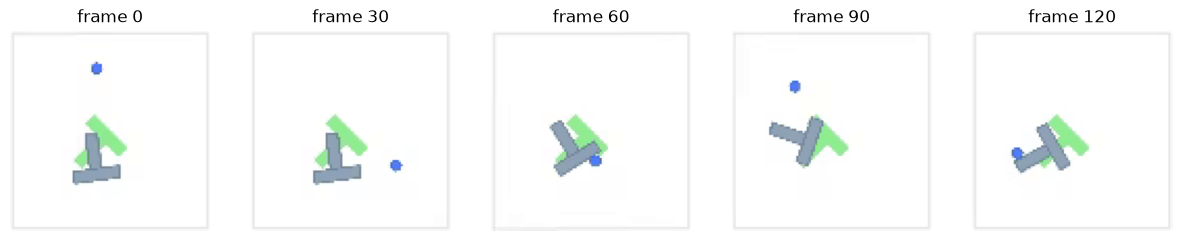

In [70]:
ds_img = LeRobotDataset("lerobot/pusht")

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i, f_i in enumerate([0, 30, 60, 90, 120]):
    img = ds_img[f_i]["observation.image"].permute(1,2,0)
    axes[i].imshow(img)
    axes[i].set_title(f"frame {f_i}")
    axes[i].axis("off")
plt.show()

In [72]:
ds_plain = LeRobotDataset("lerobot/pusht")
for i in [100, 101, 102]:
    s = ds_plain[i]["observation.state"]
    a = ds_plain[i]["action"]
    s_next = ds_plain[i+1]["observation.state"]
    print(f"state[t]={s.tolist()}  action[t]={a.tolist()}  state[t+1]={s_next.tolist()}")

Fetching 4 files: 100%|███████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 943.92it/s]

state[t]=[102.658447265625, 224.2418975830078]  action[t]=[96.0, 235.0]  state[t+1]=[99.363525390625, 229.16314697265625]
state[t]=[99.363525390625, 229.16314697265625]  action[t]=[95.0, 237.0]  state[t+1]=[97.33636474609375, 232.67367553710938]
state[t]=[97.33636474609375, 232.67367553710938]  action[t]=[95.0, 241.0]  state[t+1]=[96.16172790527344, 236.00535583496094]
